# Multivariate Time-Series Forecasting

## Exploratory Data Analysis (EDA)

### Project Objective

The objective of this project is to analyze historical retail sales data and identify important patterns, trends, seasonality, demand sparsity, store-level differences, event effects, and price-sales relationships.

The findings from this EDA will be used to make informed decisions during preprocessing, feature engineering, and time-series forecasting model development.

## 1. Dataset Overview

The project uses multiple CSV files containing historical sales, calendar information, weekly selling prices, evaluation-period sales, and the required submission format.

### Files Used

- `sales_train_validation.csv` — historical daily sales used for analysis and model development
- `calendar.csv` — date, weekday, month, year, events, and SNAP information
- `sell_prices.csv` — weekly selling prices by item and store
- `sales_train_evaluation.csv` — evaluation-period sales
- `sample_submission.csv` — submission format reference

The raw files are kept separate because each file serves a different purpose. They will be combined later during preprocessing and feature engineering.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving sell_prices.csv to sell_prices.csv
Saving sales_train_evaluation.csv to sales_train_evaluation.csv
Saving sales_train_validation.csv to sales_train_validation.csv
Saving sample_submission.csv to sample_submission.csv
Saving calendar.csv to calendar.csv


In [2]:
import os

for file_name in uploaded.keys():
    file_path = os.path.join("/content", file_name)
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)

    print(f"{file_name}  →  {file_size_mb:.2f} MB")

sell_prices.csv  →  193.97 MB
sales_train_evaluation.csv  →  116.10 MB
sales_train_validation.csv  →  114.45 MB
sample_submission.csv  →  4.99 MB
calendar.csv  →  0.10 MB


## 2. Dataset Dimensions

### Findings

- `sell_prices.csv`: 6,841,121 rows × 4 columns
- `sales_train_validation.csv`: 30,490 rows × 1,919 columns
- `sales_train_evaluation.csv`: 30,490 rows × 1,947 columns
- `calendar.csv`: 1,969 rows × 14 columns

The sales dataset is stored in a wide format, where each daily sales observation is represented by a separate `d_` column.

In [3]:
import pandas as pd
import os

files_info = [
    "sell_prices.csv",
    "sales_train_evaluation.csv",
    "sales_train_validation.csv",
    "sample_submission.csv",
    "calendar.csv"
]

for file_name in files_info:
    file_path = f"/content/{file_name}"

    # Read only the header
    df_sample = pd.read_csv(file_path, nrows=5)

    # Count rows without loading the complete dataset
    with open(file_path, "rb") as f:
        row_count = sum(1 for _ in f) - 1

    print("=" * 70)
    print(f"FILE: {file_name}")
    print(f"Rows    : {row_count:,}")
    print(f"Columns : {len(df_sample.columns)}")
    print("Columns :", list(df_sample.columns))

FILE: sell_prices.csv
Rows    : 6,841,121
Columns : 4
Columns : ['store_id', 'item_id', 'wm_yr_wk', 'sell_price']
FILE: sales_train_evaluation.csv
Rows    : 30,490
Columns : 1947
Columns : ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_84', 'd_85', 'd_86', 'd_87', 'd_88', 'd_89', 'd_90', 'd_91', 'd_92', 'd_93', 'd_94', 'd_95

### Observation

The dataset consists of multiple files serving different roles. The sales data is stored in a wide format, with each daily observation represented by a separate `d_` column.

## 3. Product, Store and Category Analysis

In [4]:
import pandas as pd

sales_items = pd.read_csv(
    "sales_train_validation.csv",
    usecols=["item_id"]
)

print("Unique products:", sales_items["item_id"].nunique())
print("Total rows:", len(sales_items))

Unique products: 3049
Total rows: 30490


In [5]:
import pandas as pd

sales_info = pd.read_csv(
    "sales_train_validation.csv",
    usecols=[
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id"
    ]
)

print("Unique Products   :", sales_info["item_id"].nunique())
print("Unique Stores     :", sales_info["store_id"].nunique())
print("Unique Departments:", sales_info["dept_id"].nunique())
print("Unique Categories  :", sales_info["cat_id"].nunique())
print("Unique States     :", sales_info["state_id"].nunique())

Unique Products   : 3049
Unique Stores     : 10
Unique Departments: 7
Unique Categories  : 3
Unique States     : 3


### Findings

- 3,049 unique products
- 10 unique stores
- 7 unique departments
- 3 unique categories
- 3 unique states

The dataset contains substantial variation across products and stores. Therefore, product-level and store-level information should be retained during preprocessing and feature engineering.

## 4. Date Range and Temporal Coverage



In [6]:
calendar = pd.read_csv("calendar.csv")

print("Shape:", calendar.shape)
print("\nColumns:")
print(calendar.columns.tolist())

print("\nFirst 5 rows:")
display(calendar.head())

print("\nLast 5 rows:")
display(calendar.tail())

Shape: (1969, 14)

Columns:
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

First 5 rows:


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1



Last 5 rows:


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0
1968,2016-06-19,11621,Sunday,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0


### Findings

The calendar covers:

- Start date: 2011-01-29
- End date: 2016-06-19
- Total calendar days: 1,969

The sales validation dataset contains 1,913 daily observations.

The beginning and ending months are partial periods, so they should be interpreted carefully when comparing monthly totals.

## 5. Missing Value Analysis



In [7]:
sales_meta = pd.read_csv(
    "sales_train_validation.csv",
    usecols=[
        "id",
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id"
    ]
)

print("Missing values in metadata columns:\n")
print(sales_meta.isnull().sum())

Missing values in metadata columns:

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
dtype: int64


In [8]:
import pandas as pd

file_path = "sales_train_validation.csv"

total_missing = 0
total_values = 0

for chunk in pd.read_csv(file_path, chunksize=2000):

    sales_data = chunk.iloc[:, 6:]   # d_1 onwards

    total_missing += sales_data.isna().sum().sum()
    total_values += sales_data.size

print("Total sales values :", f"{total_values:,}")
print("Missing sales values:", f"{total_missing:,}")

if total_missing == 0:
    print("\nNo missing values found in sales columns.")
else:
    print("\nMissing values are present in sales columns.")

Total sales values : 58,327,370
Missing sales values: 0

No missing values found in sales columns.


### Findings

No missing values were found in the identifier columns or the daily sales observations.

Therefore:

- No missing-value imputation is required for the sales observations.
- Zero sales should not be treated as missing values.

## 6. Zero-Sales / Demand Sparsity


In [9]:
import pandas as pd

file_path = "sales_train_validation.csv"

total_sales_values = 0
total_zero_sales = 0

for chunk in pd.read_csv(file_path, chunksize=2000):

    sales_data = chunk.iloc[:, 6:]

    total_sales_values += sales_data.size
    total_zero_sales += (sales_data == 0).sum().sum()

zero_sales_percentage = (total_zero_sales / total_sales_values) * 100

print("Total sales observations :", f"{total_sales_values:,}")
print("Total zero-sales values  :", f"{total_zero_sales:,}")
print("Zero-sales percentage    :", f"{zero_sales_percentage:.2f}%")

Total sales observations : 58,327,370
Total zero-sales values  : 39,777,094
Zero-sales percentage    : 68.20%


### Findings

Approximately 68.20% of all sales observations are zero.

This indicates highly sparse demand across the product-store combinations.

### Modeling Implication

Zero sales represent actual observed demand and should be retained.

They should NOT be replaced with missing values or removed during preprocessing.

The high proportion of zeros should also be considered when selecting forecasting models and evaluating predictions.

## 7. Top-Selling Products



In [10]:
import pandas as pd

file_path = "sales_train_validation.csv"

product_sales = {}

for chunk in pd.read_csv(file_path, chunksize=2000):

    sales_cols = chunk.columns[6:]

    chunk["total_sales"] = chunk[sales_cols].sum(axis=1)

    product_totals = chunk.groupby("item_id")["total_sales"].sum()

    for item, sales in product_totals.items():
        product_sales[item] = product_sales.get(item, 0) + sales

top_products = (
    pd.Series(product_sales)
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Total Historical Sales:\n")
print(top_products)

Top 10 Products by Total Historical Sales:

FOODS_3_090    1002529
FOODS_3_586     920242
FOODS_3_252     565299
FOODS_3_555     491287
FOODS_3_714     396172
FOODS_3_587     396119
FOODS_3_694     390001
FOODS_3_226     363082
FOODS_3_202     295689
FOODS_3_723     284333
dtype: int64


### Findings

The highest-selling products include:

1. `FOODS_3_090`
2. `FOODS_3_586`
3. `FOODS_3_252`
4. `FOODS_3_555`
5. `FOODS_3_714`

`FOODS_3_090` has the highest aggregate sales among the products analyzed.

Sales are not uniformly distributed across products, indicating substantial heterogeneity in product demand.

## 8. Store-wise Sales Analysis



In [11]:
import pandas as pd

file_path = "sales_train_validation.csv"

store_sales = {}

for chunk in pd.read_csv(
    file_path,
    usecols=lambda col: col in ["store_id"] or col.startswith("d_"),
    chunksize=2000
):

    sales_cols = [col for col in chunk.columns if col.startswith("d_")]

    chunk["total_sales"] = chunk[sales_cols].sum(axis=1)

    store_totals = chunk.groupby("store_id")["total_sales"].sum()

    for store, sales in store_totals.items():
        store_sales[store] = store_sales.get(store, 0) + sales

store_sales = (
    pd.Series(store_sales)
    .sort_values(ascending=False)
)

print("Total sales by store:\n")
print(store_sales)

Total sales by store:

CA_3    11188180
CA_1     7698216
TX_2     7214384
WI_2     6544012
WI_3     6427782
TX_3     6089330
CA_2     5685475
TX_1     5595292
WI_1     5149062
CA_4     4103676
dtype: int64


### Findings

There is substantial variation in aggregate sales across stores.

`CA_3` has the highest aggregate sales, while `CA_4` has the lowest among the ten stores.

### Modeling Implication

Store-level information should be retained as an important categorical feature because demand behavior differs across stores.

## 9. Category-wise Sales Analysis



In [12]:
import pandas as pd

file_path = "sales_train_validation.csv"

category_sales = {}

for chunk in pd.read_csv(
    file_path,
    usecols=lambda col: col in ["cat_id"] or col.startswith("d_"),
    chunksize=2000
):

    sales_cols = [col for col in chunk.columns if col.startswith("d_")]

    chunk["total_sales"] = chunk[sales_cols].sum(axis=1)

    category_totals = chunk.groupby("cat_id")["total_sales"].sum()

    for category, sales in category_totals.items():
        category_sales[category] = category_sales.get(category, 0) + sales

category_sales = (
    pd.Series(category_sales)
    .sort_values(ascending=False)
)

print("Total sales by category:\n")
print(category_sales)

Total sales by category:

FOODS        45089939
HOUSEHOLD    14480670
HOBBIES       6124800
dtype: int64


### Findings

Aggregate sales by category:

- FOODS: 45,089,939
- HOUSEHOLD: 14,480,670
- HOBBIES: 6,124,800

FOODS accounts for the largest share of total sales.

### Modeling Implication

Category information should be retained during preprocessing because demand differs substantially between categories.

## 10. Overall Time Trend



In [13]:
import pandas as pd

file_path = "sales_train_validation.csv"

daily_sales = {}

for chunk in pd.read_csv(
    file_path,
    usecols=lambda col: col.startswith("d_"),
    chunksize=2000
):
    for col in chunk.columns:
        daily_sales[col] = daily_sales.get(col, 0) + chunk[col].sum()

daily_sales = pd.Series(daily_sales)

print("Number of days:", len(daily_sales))
print("\nFirst 10 days:")
print(daily_sales.head(10))

print("\nLast 10 days:")
print(daily_sales.tail(10))

Number of days: 1913

First 10 days:
d_1     32631
d_2     31749
d_3     23783
d_4     25412
d_5     19146
d_6     29211
d_7     28010
d_8     37932
d_9     32736
d_10    25572
dtype: int64

Last 10 days:
d_1904    41789
d_1905    48362
d_1906    51640
d_1907    38059
d_1908    37570
d_1909    35343
d_1910    35033
d_1911    40517
d_1912    48962
d_1913    49795
dtype: int64


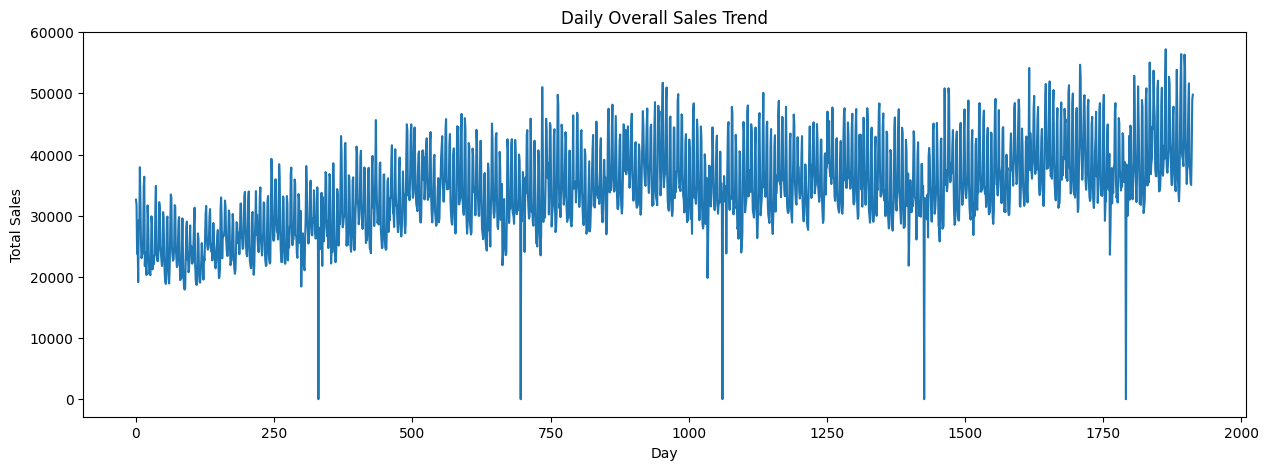

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(daily_sales.values)

plt.title("Daily Overall Sales Trend")
plt.xlabel("Day")
plt.ylabel("Total Sales")

plt.show()

### Findings

Daily aggregate sales show a clear upward trend over the observed period, along with substantial day-to-day fluctuations.

### Modeling Implication

Time-related information is important for forecasting.

The modeling pipeline should preserve chronological order and avoid random train-test splitting.

## 11. Monthly Sales Trend

In [15]:
calendar = pd.read_csv("calendar.csv")

calendar["date"] = pd.to_datetime(calendar["date"])

day_to_date = calendar.set_index("d")["date"]

daily_df = daily_sales.rename("sales").reset_index()
daily_df.columns = ["d", "sales"]

daily_df["date"] = daily_df["d"].map(day_to_date)

daily_df["month"] = daily_df["date"].dt.to_period("M")

monthly_sales = daily_df.groupby("month")["sales"].sum()

print("Number of months:", len(monthly_sales))
print("\nFirst 10 months:")
print(monthly_sales.head(10))

print("\nLast 10 months:")
print(monthly_sales.tail(10))

Number of months: 64

First 10 months:
month
2011-01     88163
2011-02    726375
2011-03    763567
2011-04    737713
2011-05    719562
2011-06    753380
2011-07    819820
2011-08    825694
2011-09    813683
2011-10    898243
Freq: M, Name: sales, dtype: int64

Last 10 months:
month
2015-07    1232147
2015-08    1254341
2015-09    1188913
2015-10    1248437
2015-11    1113976
2015-12    1126236
2016-01    1215286
2016-02    1212927
2016-03    1275746
2016-04    1046688
Freq: M, Name: sales, dtype: int64


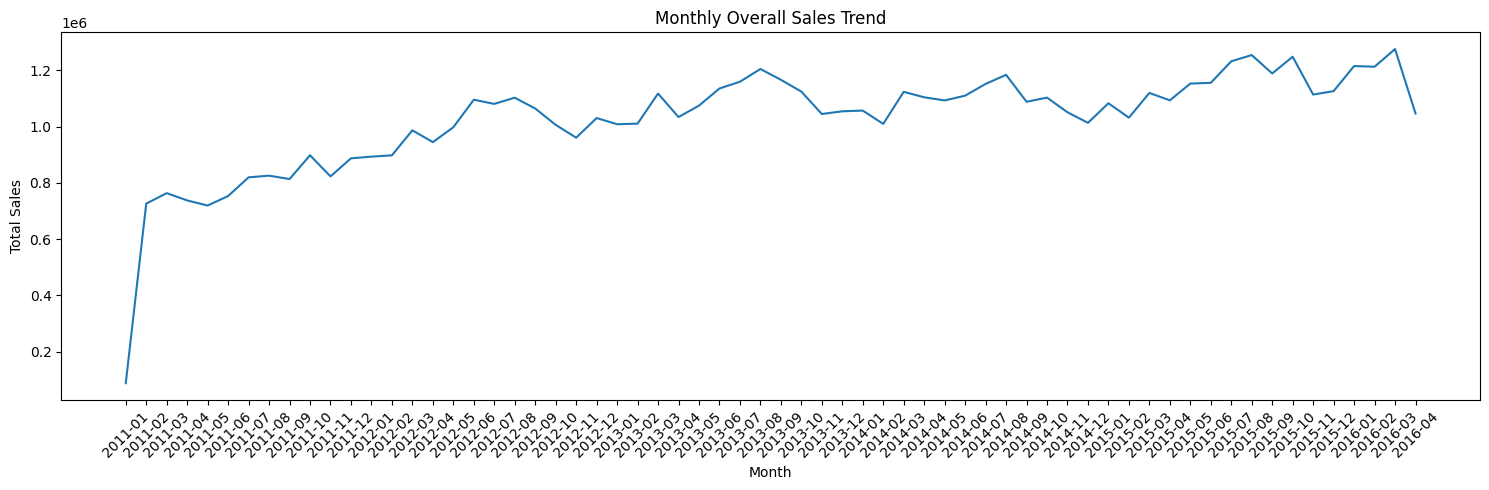

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title("Monthly Overall Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Findings

The monthly sales trend confirms the overall upward movement in demand over time. The first and last months are partial periods and should therefore be interpreted carefully.

## 12. Weekly Seasonality



In [17]:
# Map each day to its calendar information
calendar_small = calendar[["d", "date", "weekday"]].copy()

weekly_df = daily_df.merge(
    calendar_small,
    on=["d", "date"],
    how="left"
)

weekly_sales = (
    weekly_df
    .groupby("weekday")["sales"]
    .mean()
    .sort_values(ascending=False)
)

print("Average daily sales by weekday:\n")
print(weekly_sales)

Average daily sales by weekday:

weekday
Saturday     41546.894161
Sunday       41130.021898
Friday       34225.985348
Monday       32852.967033
Tuesday      30368.780220
Thursday     30205.007326
Wednesday    30010.021978
Name: sales, dtype: float64


### Findings

A strong day-of-week pattern is present.

Average daily sales are highest on Saturday and Sunday and generally lower during the middle of the week.

Saturday has substantially higher average sales than Wednesday.

### Modeling Implication

Day-of-week information should be included as a forecasting feature.

Lag-based features such as 7-day and 14-day lags are also likely to be useful.

## 13. Monthly Seasonality



In [18]:
# Month number from calendar date
daily_df["month_num"] = daily_df["date"].dt.month

monthly_pattern = (
    daily_df
    .groupby("month_num")["sales"]
    .mean()
)

print("Average daily sales by month:\n")
print(monthly_pattern)

Average daily sales by month:

month_num
1     33832.348101
2     34644.641176
3     34339.838710
4     34258.683908
5     32503.851613
6     35001.413333
7     35122.419355
8     35946.645161
9     35479.260000
10    34713.477419
11    33290.826667
12    32980.464516
Name: sales, dtype: float64


### Findings

Monthly variation exists but is weaker than the observed weekly pattern.

Average sales are highest around August and lowest around May in the analyzed data.

### Modeling Implication

Month/season information may provide additional predictive information, but weekly patterns appear more prominent.

## 14. Events and SNAP Analysis

In [19]:
# Identify whether a day has any event
calendar["has_event"] = (
    calendar["event_name_1"].notna() |
    calendar["event_name_2"].notna()
)

# Keep only the calendar information we need
event_df = daily_df.merge(
    calendar[["d", "has_event"]],
    on="d",
    how="left"
)

# Compare average daily sales
event_sales = (
    event_df
    .groupby("has_event")["sales"]
    .mean()
)

print("Average daily sales:\n")
print(event_sales)

print("\nEvent days:", event_df["has_event"].sum())
print("Non-event days:", (~event_df["has_event"]).sum())

Average daily sales:

has_event
False    34489.207504
True     32655.149351
Name: sales, dtype: float64

Event days: 154
Non-event days: 1759


In [20]:
# Create an overall SNAP indicator
calendar["has_snap"] = (
    (calendar["snap_CA"] == 1) |
    (calendar["snap_TX"] == 1) |
    (calendar["snap_WI"] == 1)
)

snap_df = daily_df.merge(
    calendar[["d", "has_snap"]],
    on="d",
    how="left"
)

snap_sales = (
    snap_df
    .groupby("has_snap")["sales"]
    .mean()
)

print("Average daily sales:\n")
print(snap_sales)

print("\nSNAP days:", snap_df["has_snap"].sum())
print("Non-SNAP days:", (~snap_df["has_snap"]).sum())

Average daily sales:

has_snap
False    32554.064050
True     36172.566138
Name: sales, dtype: float64

SNAP days: 945
Non-SNAP days: 968


In [21]:
for state in ["CA", "TX", "WI"]:

    snap_col = f"snap_{state}"

    state_sales = daily_df.merge(
        calendar[["d", snap_col]],
        on="d",
        how="left"
    )

    result = (
        state_sales
        .groupby(snap_col)["sales"]
        .mean()
    )

    print(f"\n{state} SNAP:")
    print(result)


CA SNAP:
snap_CA
0    33408.506625
1    36241.738095
Name: sales, dtype: float64

TX SNAP:
snap_TX
0    33263.012471
1    36538.038095
Name: sales, dtype: float64

WI SNAP:
snap_WI
0    33239.736555
1    36585.439683
Name: sales, dtype: float64


### Event Findings

Average sales on event days were approximately 32,655 compared with approximately 34,489 on non-event days.

This indicates a negative association between the presence of an event and aggregate sales in this dataset.

This should NOT be interpreted as a causal effect because event occurrence may be correlated with weekday, month, or other factors.

### SNAP Findings

Average sales on SNAP days were approximately 36,173 compared with approximately 32,554 on non-SNAP days.

The positive association was also observed across CA, TX, and WI.

### Modeling Implication

Calendar event and SNAP indicators should be retained as potential predictive features.

## 15. Price vs Sales Relationship



In [22]:
import pandas as pd

# --------------------------------------------------
# 1. Daily sales ko weekly sales mein aggregate karo
# --------------------------------------------------

# Sales metadata + daily columns
sales_file = "sales_train_validation.csv"

weekly_sales = {}

for chunk in pd.read_csv(
    sales_file,
    usecols=lambda col: col in ["item_id", "store_id"] or col.startswith("d_"),
    chunksize=2000
):

    sales_cols = [col for col in chunk.columns if col.startswith("d_")]

    # Daily -> weekly mapping
    chunk_long = chunk.melt(
        id_vars=["item_id", "store_id"],
        value_vars=sales_cols,
        var_name="d",
        value_name="sales"
    )

    chunk_long = chunk_long.merge(
        calendar[["d", "wm_yr_wk"]],
        on="d",
        how="left"
    )

    weekly_chunk = (
        chunk_long
        .groupby(["item_id", "store_id", "wm_yr_wk"])["sales"]
        .sum()
        .reset_index()
    )

    weekly_sales[len(weekly_sales)] = weekly_chunk

weekly_sales = pd.concat(weekly_sales.values(), ignore_index=True)

weekly_sales = (
    weekly_sales
    .groupby(["item_id", "store_id", "wm_yr_wk"])["sales"]
    .sum()
    .reset_index()
)

print("Weekly sales shape:", weekly_sales.shape)
print(weekly_sales.head())

Weekly sales shape: (8354260, 4)
       item_id store_id  wm_yr_wk  sales
0  FOODS_1_001     CA_1     11101     10
1  FOODS_1_001     CA_1     11102      6
2  FOODS_1_001     CA_1     11103     10
3  FOODS_1_001     CA_1     11104     13
4  FOODS_1_001     CA_1     11105     15


In [23]:
price_file = "sell_prices.csv"

price_chunks = []

for chunk in pd.read_csv(
    price_file,
    usecols=["store_id", "item_id", "wm_yr_wk", "sell_price"],
    chunksize=500000
):
    price_chunks.append(chunk)

sell_prices = pd.concat(price_chunks, ignore_index=True)

print("Price data shape:", sell_prices.shape)
print(sell_prices.head())

Price data shape: (6841121, 4)
  store_id        item_id  wm_yr_wk  sell_price
0     CA_1  HOBBIES_1_001     11325        9.58
1     CA_1  HOBBIES_1_001     11326        9.58
2     CA_1  HOBBIES_1_001     11327        8.26
3     CA_1  HOBBIES_1_001     11328        8.26
4     CA_1  HOBBIES_1_001     11329        8.26


In [24]:
# Merge weekly sales with selling price
price_sales = weekly_sales.merge(
    sell_prices,
    on=["item_id", "store_id", "wm_yr_wk"],
    how="inner"
)

print("Merged data shape:", price_sales.shape)
print("\nMissing values:")
print(price_sales[["sales", "sell_price"]].isna().sum())

print("\nSample:")
print(price_sales.head())

Merged data shape: (6597201, 5)

Missing values:
sales         0
sell_price    0
dtype: int64

Sample:
       item_id store_id  wm_yr_wk  sales  sell_price
0  FOODS_1_001     CA_1     11101     10         2.0
1  FOODS_1_001     CA_1     11102      6         2.0
2  FOODS_1_001     CA_1     11103     10         2.0
3  FOODS_1_001     CA_1     11104     13         2.0
4  FOODS_1_001     CA_1     11105     15         2.0


In [25]:
price_sales_corr = price_sales[["sell_price", "sales"]].corr().loc[
    "sell_price", "sales"
]

print("Pearson correlation between price and sales:", price_sales_corr)

Pearson correlation between price and sales: -0.17312988979236363


In [26]:
# Create 4 price groups using quartiles
price_sales["price_bucket"] = pd.qcut(
    price_sales["sell_price"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

price_bucket_sales = (
    price_sales
    .groupby("price_bucket", observed=True)["sales"]
    .mean()
)

print("Average weekly sales by price bucket:\n")
print(price_bucket_sales)

Average weekly sales by price bucket:

price_bucket
Low            20.221357
Medium-Low      8.839455
Medium-High     6.141631
High            4.295751
Name: sales, dtype: float64


### Findings

The Pearson correlation between selling price and weekly sales was approximately -0.173.

Average weekly sales decreased consistently across the four price groups:

| Price Group | Average Weekly Sales |
|---|---:|
| Low | 20.22 |
| Medium-Low | 8.84 |
| Medium-High | 6.14 |
| High | 4.30 |

This indicates a negative association between price and sales.

However, this relationship should not be interpreted as causal because product, store, category, seasonality, promotions, and other factors may influence both price and sales.

### Modeling Implication

Selling price should be considered as a potential explanatory feature during feature engineering.

# 16. Key EDA Findings

The major patterns identified during exploratory analysis are:

1. The dataset contains 3,049 products across 10 stores.
2. Sales data contains no missing sales observations.
3. Approximately 68.20% of sales observations are zero, indicating highly sparse demand.
4. Aggregate sales show a clear upward trend over time.
5. Strong weekly seasonality is present.
6. Monthly seasonality exists but is weaker than weekly seasonality.
7. Sales vary substantially across stores.
8. FOODS is the dominant sales category.
9. Some products contribute substantially more sales than others.
10. SNAP days show higher average sales than non-SNAP days.
11. Event days show lower average sales in the analyzed data, although this is an association rather than a causal relationship.
12. Selling price has a negative association with weekly sales.

# 17. Modeling Implications

Based on the EDA, the forecasting pipeline should:

- Preserve zero-sales observations because they represent actual demand.
- Preserve chronological ordering of observations.
- Include product and store identifiers.
- Include category and department information.
- Include calendar-based features such as day of week, month, and year.
- Consider event indicators.
- Include SNAP indicators.
- Include selling price as a potential explanatory variable.
- Use lag-based features to capture temporal dependence.
- Use rolling statistics to capture recent demand patterns.
- Avoid random train-test splitting because this is a time-series forecasting problem.
- Carefully handle the partial periods at the beginning and end of the dataset.

# 18. Conclusion

The EDA reveals that the retail sales data contains strong temporal structure, substantial product and store heterogeneity, highly sparse demand, weekly seasonality, an overall upward trend, and relationships with calendar events, SNAP availability, and selling price.

These findings provide the basis for the preprocessing and feature engineering strategy.

The next stage will transform the raw wide-format sales data into a modeling-ready time-series structure and combine the required calendar and price information.